# Practical 1 report: preparing biological data for machine learning

**Student:** Fisun Yelyzaveta  
**Date:** 19.09  
**Practical:** 1 - Data to ML-ready format

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [40]:
RANDOM_STATE = 1102026

## 2. Data-preparation readiness

Complete this section before describing modelling results.

## Scientific purpose and provenance

- [x] Is the biological question and prediction task stated clearly? \
I will predict Genotype (Control vs Trisomy) (target) by analyzing expression levels of proteins (features).
- [x] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)? \
Yeah, unit of observation is mouse.
- [x] Have I recorded the data version, processing history, and transformations already applied? \
Data was last updated 8/3/2015. Protein expression levels were normalized to range 0-1.

## Table shape and identifiers

- [x] Is the table tidy: one observation per row, one variable per column, and one value per cell? \
No, for each mouse we have 15 observations (three replicates of a five-point dilution series)
- [x] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool? \
Original assay has features in columns and samples in rows already.
- [x] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns? \
Probably i will add some addition column as derived id which will be unique per each mouse, so 15 measurements per each sample will be summarized as one row. I will take the average value of first level of dillution.
- [x] Can every feature and observation be traced back to its source? \
yes
- [x] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order? \
In this case features and metadata are in one data frame.

In [2]:
data = pd.read_excel("Data_Cortex_Nuclear.xls")

In [3]:
data.shape

(1080, 82)

In [4]:
data.columns

Index(['MouseID', 'DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N',
       'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N', 'pJNK_N',
       'PKCA_N', 'pMEK_N', 'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pPKCAB_N',
       'pRSK_N', 'AKT_N', 'BRAF_N', 'CAMKII_N', 'CREB_N', 'ELK_N', 'ERK_N',
       'GSK3B_N', 'JNK_N', 'MEK_N', 'TRKA_N', 'RSK_N', 'APP_N', 'Bcatenin_N',
       'SOD1_N', 'MTOR_N', 'P38_N', 'pMTOR_N', 'DSCR1_N', 'AMPKA_N', 'NR2B_N',
       'pNUMB_N', 'RAPTOR_N', 'TIAM1_N', 'pP70S6_N', 'NUMB_N', 'P70S6_N',
       'pGSK3B_N', 'pPKCG_N', 'CDK5_N', 'S6_N', 'ADARB1_N', 'AcetylH3K9_N',
       'RRP1_N', 'BAX_N', 'ARC_N', 'ERBB4_N', 'nNOS_N', 'Tau_N', 'GFAP_N',
       'GluR3_N', 'GluR4_N', 'IL1B_N', 'P3525_N', 'pCASP9_N', 'PSD95_N',
       'SNCA_N', 'Ubiquitin_N', 'pGSK3B_Tyr216_N', 'SHH_N', 'BAD_N', 'BCL2_N',
       'pS6_N', 'pCFOS_N', 'SYP_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N',
       'CaNA_N', 'Genotype', 'Treatment', 'Behavior', 'class'],
      dtype='str')

## Types, values, and measurement meaning

- [x] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
Yes, all protein expression levels are numerical and metadata is string.  
- [x] Are units, scales, encodings, reference categories, and detection limits understood?  
yes
- [x] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?  
yes
- [x] Are normalization, scaling, log transformation, and batch-correction steps documented?  
In the article they mentioned that they did normalization of protein expressions in range 0-1, but i checked max value for each protein and i see value greater than 1. Also I noticed that not all proteins has all 1080 measuraments. In the articl eit states 

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   str    
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   float64
 17  pNR2B_N          1077 non

## Missing values

- [x] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
- [x] Have I measured missingness by row, column, group, and relevant batch or time variable?
- [x] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
not really, maybe the exression of these proteins is so low, so it can't pe captured by device. 
- [x] Have I justified whether to retain, remove, or impute missing values?
I decided to impute missing values, because otherwise we can loose sample which is not prefered.
- [x] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?  
I imputed using different method, i grouped dataset by class and impute missing values of proteins by mean value of this protein in the specific class.

In [8]:
data.shape

(1080, 82)

In [7]:
protein_cols = [c for c in data.columns if c.endswith("_N")]
missing_by_column = data[protein_cols].isna().sum()
missing_by_row = data[protein_cols].isna().sum(axis=1)

print("Total missing expression cells:", int(missing_by_column.sum()))
print("Features with at least one missing value:", int((missing_by_column > 0).sum()))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))

display(missing_by_column[missing_by_column > 0].head())
missing_by_row.describe()

Total missing expression cells: 1396
Features with at least one missing value: 49
Rows with at least one missing value: 528


DYRK1A_N    3
ITSN1_N     3
BDNF_N      3
NR1_N       3
NR2A_N      3
dtype: int64

count    1080.000000
mean        1.292593
std         2.650396
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        43.000000
dtype: float64

## Replicates, dependence, and grouping

- [x] Have I checked for exact duplicates and near-duplicate observations?
- [x] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [x] Is the independent biological unit identified by a grouping variable?
- [x] Will all related observations and their derivatives remain in the same train/validation/test split?
- [x] If I created augmented or synthetic observations, is their provenance recorded and reproducible?

I group data in such way:
1) Add derived id
2) Find average value in first three measuraments (lowest dilution)

In [10]:
data["mouse_id"] = data["MouseID"].astype(str).str.rsplit("_", n=1).str[0]

In [12]:
meta_cols = ['Genotype', 'Treatment', 'Behavior', 'class']     # metadata to keep

# Define the aggregation rule for each column
agg_dict = {col: 'mean' for col in protein_cols}
agg_dict.update({col: 'first' for col in meta_cols})

summary_df = (
    data.groupby('mouse_id')
    .head(3)
    .groupby('mouse_id')
    .agg(agg_dict)
    .reset_index()
)

In [13]:
summary_df

,mouse_id,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,18899,0.516191,0.725163,0.332351,2.273460,4.369364,0.265365,0.186989,2.609932,0.194738,...,NaN,0.391265,0.158987,NaN,0.183298,1.317442,Ts65Dn,Saline,C/S,t-CS-s
1,293,0.334238,0.619685,0.310475,2.533279,4.199819,0.248167,0.193802,4.368996,0.247788,...,0.099993,0.509923,0.388605,0.149769,0.278735,1.218029,Ts65Dn,Memantine,S/C,t-SC-m
2,294,0.318412,0.506520,0.306461,2.570542,4.425564,0.229366,0.169936,5.500843,0.218851,...,0.121452,0.465763,NaN,0.185326,0.174852,0.999949,Control,Memantine,S/C,c-SC-m
3,309,0.509148,0.722168,0.420085,2.764348,5.765749,0.213159,0.175368,2.316410,0.229814,...,0.106290,0.434819,0.112880,0.133418,0.128912,1.781896,Control,Memantine,C/S,c-CS-m
4,311,0.719744,0.824081,0.359814,2.583459,5.737181,0.207847,0.172124,2.167861,0.180185,...,NaN,0.449668,0.119235,0.161959,0.160248,1.354964,Control,Memantine,C/S,c-CS-m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,50810E,0.599066,0.930390,0.382264,2.643460,4.528335,0.205800,0.167278,2.925369,0.238012,...,0.117181,0.575132,0.182868,0.146164,0.174507,1.776976,Ts65Dn,Saline,C/S,t-CS-s
68,50810F,0.533877,0.627208,0.334449,2.324317,5.019051,0.247039,0.202400,3.753689,0.234677,...,0.093036,0.282538,NaN,NaN,NaN,1.488283,Control,Saline,C/S,c-CS-s
69,J1291,0.284555,0.521601,0.322131,2.391741,3.472661,0.238917,0.188060,3.759763,0.249554,...,NaN,0.312337,0.287654,0.129780,0.225484,1.343898,Ts65Dn,Saline,S/C,t-SC-s
70,J2292,0.276184,0.475245,0.395732,2.570005,5.084154,0.227035,0.171027,5.633468,0.214216,...,0.119947,0.548758,0.202137,0.182157,0.172664,1.213320,Control,Saline,S/C,c-SC-s


## Target, leakage, and study design

- [x] Is the target defined before modelling, with its classes or values checked for balance and validity?
yes, it will genotype. 
- [x] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
for features i will use only protein levels. 
- [x] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
- [x] Have I checked whether the target is associated with a technical or grouping variable?
- [x] Does the planned split represent the biological generalization question?

## Reproducibility and decision record

- [x] Are random seeds, software versions, file names, and input/output shapes recorded?
- [x] Are all preprocessing steps placed in a reproducible pipeline?
- [x] Have I recorded unresolved data-quality concerns and the decisions made about them?
- [x] Can another person explain what each row, column, feature, target, and grouping variable means?

### 3.1 Data presentation

Describe:
- what one row represents 
- what one biological mouse represents 
- `MouseID` and derived `mouse_id` 
- `Genotype`, `Treatment`, `Behavior`, and `class` 
- the prediction target selected.

**Answers:**  
- One row is one measurement at specific level of dilution for each mouse replicates. We have 5 levels of diltion and 3 replicates for each and such it is for every mouse. 
- One mouse is one sample
- derived `mouse_id` is id uniquely iassigned for each mouse. `MouseID` is id of measurament.
- Genotype (Cotrol vs Ts65Dn); Behavior (S/C - shock context, simulated to learn; C/S - context show); Treatment (Memantine, Saline);  
Classes:  
c-CS-s: control mice, stimulated to learn, injected with saline (9 mice). 
c-CS-m: control mice, stimulated to learn, injected with memantine (10 mice). 
c-SC-s: control mice, not stimulated to learn, injected with saline (9 mice). 
c-SC-m: control mice, not stimulated to learn, injected with memantine (10 mice). 

t-CS-s: trisomy mice, stimulated to learn, injected with saline (7 mice). 
t-CS-m: trisomy mice, stimulated to learn, injected with memantine (9 mice). 
t-SC-s: trisomy mice, not stimulated to learn, injected with saline (9 mice). 
t-SC-m: trisomy mice, not stimulated to learn, injected with memantine (9 mice). 

- Target is Genotype. To ensure we are seeing the true effect of genotype on protein expression, I am filtering the data to only include the Saline group.
- Dataframe has proteins as features, each row represents sample (mouse). Cells are expression values.

In [16]:
data['Genotype'].value_counts()

Genotype
Control    570
Ts65Dn     510
Name: count, dtype: int64

In [18]:
data['Behavior'].value_counts()

Behavior
S/C    555
C/S    525
Name: count, dtype: int64

In [19]:
data['Treatment'].value_counts()

Treatment
Memantine    570
Saline       510
Name: count, dtype: int64

In [21]:
data['class'].value_counts()

class
c-CS-m    150
c-SC-m    150
c-CS-s    135
c-SC-s    135
t-CS-m    135
t-SC-m    135
t-SC-s    135
t-CS-s    105
Name: count, dtype: int64

### 3.2 Tidy-data assessment and EDA

Report:
- rows and columns: `(72,82)` 
- unique mice: `72` 
- measurements per mouse: `one after grouping, originally it was 15 measuraments` 
- categories and counts for Genotype, Treatment, Behavior, and class: `code in previous section` 
- whether the table is tidy: `after preprocessing yes`.

Include at least three plots. For each, state the biological question it addresses.

In [20]:
summary_df.shape

(72, 82)

Is our genotype distribution balanced?

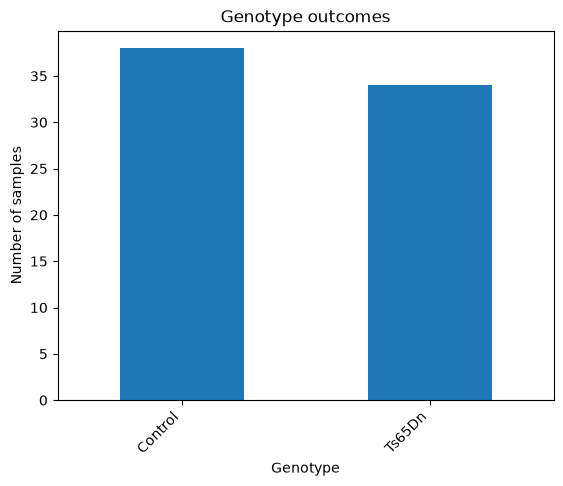

In [26]:
summary_df["Genotype"].value_counts().plot(kind="bar")
plt.ylabel("Number of samples")
plt.title("Genotype outcomes")
plt.xticks(rotation=45, ha="right")
plt.show()

### 3.3 Diagnostics

Report checks for:
- missingness in proteins and metadata: `49 proteins with at least one missing value` 
- duplicate rows or duplicate measurement identifiers: `not found` 
- expected 15 measurements per mouse: `yes, but i summarized it to one measurament` 
- unusual categories or inconsistent labels: `no` 
- non-finite, negative, or implausible expression values: `not found` 
- highly correlated or redundant protein variables: `no` 
- predictors that are deterministic parts of the target: `no`.

In [27]:
missing_by_column = summary_df[protein_cols].isna().sum()
missing_by_row = summary_df[protein_cols].isna().sum(axis=1)

print("Total missing expression cells:", int(missing_by_column.sum()))
print("Features with at least one missing value:", int((missing_by_column > 0).sum()))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))

display(missing_by_column[missing_by_column > 0].head())
missing_by_row.describe()

Total missing expression cells: 84
Features with at least one missing value: 8
Rows with at least one missing value: 35


ELK_N          1
Bcatenin_N     1
BAD_N         14
BCL2_N        19
pCFOS_N        5
dtype: int64

count    72.000000
mean      1.166667
std       1.472757
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max       5.000000
dtype: float64

In [33]:
summary_df.columns

Index(['mouse_id', 'DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N',
       'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N',
       'pJNK_N', 'PKCA_N', 'pMEK_N', 'pNR1_N', 'pNR2A_N', 'pNR2B_N',
       'pPKCAB_N', 'pRSK_N', 'AKT_N', 'BRAF_N', 'CAMKII_N', 'CREB_N', 'ELK_N',
       'ERK_N', 'GSK3B_N', 'JNK_N', 'MEK_N', 'TRKA_N', 'RSK_N', 'APP_N',
       'Bcatenin_N', 'SOD1_N', 'MTOR_N', 'P38_N', 'pMTOR_N', 'DSCR1_N',
       'AMPKA_N', 'NR2B_N', 'pNUMB_N', 'RAPTOR_N', 'TIAM1_N', 'pP70S6_N',
       'NUMB_N', 'P70S6_N', 'pGSK3B_N', 'pPKCG_N', 'CDK5_N', 'S6_N',
       'ADARB1_N', 'AcetylH3K9_N', 'RRP1_N', 'BAX_N', 'ARC_N', 'ERBB4_N',
       'nNOS_N', 'Tau_N', 'GFAP_N', 'GluR3_N', 'GluR4_N', 'IL1B_N', 'P3525_N',
       'pCASP9_N', 'PSD95_N', 'SNCA_N', 'Ubiquitin_N', 'pGSK3B_Tyr216_N',
       'SHH_N', 'BAD_N', 'BCL2_N', 'pS6_N', 'pCFOS_N', 'SYP_N', 'H3AcK18_N',
       'EGR1_N', 'H3MeK4_N', 'CaNA_N', 'Genotype', 'Treatment', 'Behavior',
       'class'],
      dtype='str')

In [ ]:
summary_df[protein_cols] = summary_df.groupby('class')[protein_cols].transform(lambda x: x.fillna(x.mean()))

missing_after = summary_df[protein_cols].isna().sum().sum()
print(f"Missing values remaining after class-mean imputation: {missing_after}")

Missing values remaining after class-mean imputation: 0


In [35]:
missing_by_column = summary_df[protein_cols].isna().sum()
missing_by_row = summary_df[protein_cols].isna().sum(axis=1)

print("Total missing expression cells:", int(missing_by_column.sum()))
print("Features with at least one missing value:", int((missing_by_column > 0).sum()))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))

display(missing_by_column[missing_by_column > 0].head())
missing_by_row.describe()

Total missing expression cells: 0
Features with at least one missing value: 0
Rows with at least one missing value: 0


Series([], dtype: int64)

count    72.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

In [28]:
print("Duplicate metadata rows:", summary_df.duplicated().sum())

Duplicate metadata rows: 0


In [29]:
print("Metadata IDs unique:", summary_df["mouse_id"].is_unique)

Metadata IDs unique: True


In [ ]:
# 1. Count Negative Values
negatives = (summary_df[protein_cols] < 0).sum().sum()

# 2. Count Infinite Values (inf or -inf)
# We fill NaNs temporarily with 0 just for the check, as isinf fails on NaNs in older pandas
infinities = np.isinf(summary_df[protein_cols].fillna(0)).sum().sum()

print("--- Data Health Report ---")
print(f"Negative values found: {negatives}")
print(f"Infinite values found: {infinities}")

--- Data Health Report ---
Negative values found: 0
Infinite values found: 0
Implausible outliers (>99.9th percentile) found: 77


### 3.4 Preparation and feature roles

Selected supervised-learning question: Predict genotype based on protein expression levels.

Missing-value decision: Group by 'class' column and fill missing protein values with that class's mean.

### 3.5 Split strategy
- Independent biological unit: `[mouse]`
- Grouping variable: `[mouse_id]`
- Split method: `[method]`

In [46]:
only_saline = summary_df[summary_df['Treatment'] == 'Saline']
row_indices = np.arange(len(only_saline))
train_idx_random, test_idx_random = train_test_split(
    row_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=only_saline["Genotype"])

random_train = only_saline.iloc[train_idx_random]
random_test = only_saline.iloc[test_idx_random]

In [47]:
random_train

,mouse_id,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
53,3525,0.443312,0.725379,0.432129,2.916678,5.830432,0.290131,0.191138,6.545185,0.293544,...,0.114501,0.466526,0.159777,0.180509,0.166124,1.188001,Ts65Dn,Saline,S/C,t-SC-s
20,3423,0.341124,0.590244,0.392888,3.139617,5.862625,0.264601,0.204521,4.317421,0.267369,...,0.108401,0.557512,0.109192,0.167095,0.164530,1.163023,Control,Saline,S/C,c-SC-s
70,J2292,0.276184,0.475245,0.395732,2.570005,5.084154,0.227035,0.171027,5.633468,0.214216,...,0.119947,0.548758,0.202137,0.182157,0.172664,1.213320,Control,Saline,S/C,c-SC-s
31,3483,0.524890,0.850059,0.346774,2.410837,3.988410,0.182356,0.151508,2.872750,0.241700,...,0.124715,0.427065,0.231183,0.155405,0.197761,1.574330,Ts65Dn,Saline,C/S,t-CS-s
47,3513,0.426887,0.688649,0.380982,2.859059,5.420487,0.257974,0.188702,6.257712,0.263347,...,0.127540,0.498624,0.138519,0.159551,0.168649,1.222590,Ts65Dn,Saline,S/C,t-SC-s
28,3479,0.483348,0.663578,0.358282,2.501787,4.548065,0.176041,0.128205,2.855774,0.198232,...,0.115615,0.447610,0.117774,0.150592,0.144012,1.562463,Control,Saline,C/S,c-CS-s
21,3424,0.378410,0.576907,0.335373,2.640631,4.779559,0.234293,0.187141,3.395009,0.215855,...,0.110280,0.487009,0.123795,0.178935,0.185086,1.096497,Control,Saline,S/C,c-SC-s
30,3481,0.299924,0.528176,0.336217,2.976868,5.263213,0.226933,0.175151,3.454381,0.229208,...,0.128090,0.523060,0.132655,0.185682,0.185086,1.103462,Control,Saline,S/C,c-SC-s
35,3490,0.348282,0.590853,0.397946,2.956389,5.373187,0.227108,0.191452,3.934138,0.290981,...,0.128447,0.576500,0.154213,0.186787,0.200734,1.270756,Control,Saline,S/C,c-SC-s
63,50810A,0.445738,0.829942,0.419766,3.017117,3.977969,0.195902,0.196766,2.374490,0.298186,...,0.144647,0.740792,0.150068,0.177763,0.169066,2.021775,Control,Saline,C/S,c-CS-s


### 3.6 Confounding and distribution structure

Investigate associations between the target and:
- treatment 
- behavior 
- genotype 
- composite class 
- number of measurements per mouse.

In [49]:
X = only_saline[protein_cols]

In [52]:
X

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
0,0.516191,0.725163,0.332351,2.273460,4.369364,0.265365,0.186989,2.609932,0.194738,1.713071,...,0.203534,0.154546,0.137930,0.122550,0.114298,0.391265,0.158987,0.141314,0.183298,1.317442
18,0.305044,0.594658,0.328852,2.064076,3.288487,0.216955,0.167655,3.343494,0.242952,0.959365,...,0.286848,0.155390,0.117523,0.121052,0.121470,0.390932,0.208265,0.168929,0.207904,1.257987
19,0.302410,0.481325,0.318793,2.610057,4.534201,0.229145,0.175073,4.234695,0.204646,1.347587,...,0.255292,0.141236,0.133643,0.145510,0.136975,0.405430,0.137316,0.181118,0.171641,0.921541
20,0.341124,0.590244,0.392888,3.139617,5.862625,0.264601,0.204521,4.317421,0.267369,1.311876,...,0.212190,0.135419,0.111266,0.142834,0.108401,0.557512,0.109192,0.167095,0.164530,1.163023
21,0.378410,0.576907,0.335373,2.640631,4.779559,0.234293,0.187141,3.395009,0.215855,1.416666,...,0.226423,0.138073,0.119553,0.140664,0.110280,0.487009,0.123795,0.178935,0.185086,1.096497
22,0.371177,0.707505,0.310664,2.356189,3.808233,0.214320,0.160210,3.491724,0.234313,1.119493,...,0.242266,0.151739,0.114851,0.124339,0.139461,0.415541,0.164514,0.163324,0.170677,1.254123
23,0.489818,0.824027,0.391029,2.637289,4.458706,0.247716,0.195311,4.164845,0.255485,1.359987,...,0.210366,0.143140,0.106351,0.120506,0.111304,0.478064,0.143761,0.146444,0.165251,1.442283
25,0.541474,0.876541,0.357006,2.655429,4.253252,0.238768,0.184216,4.666462,0.293478,1.514393,...,0.243869,0.148253,0.116576,0.119553,0.115751,0.530417,0.174060,0.156202,0.165459,1.778325
26,0.593442,0.847155,0.428022,2.809357,5.502783,0.273615,0.192415,4.315340,0.274722,1.837998,...,0.222502,0.131620,0.108385,0.121696,0.105994,0.392548,0.157442,0.139314,0.151990,1.380953
27,0.443347,0.731009,0.438389,2.963196,5.427362,0.236094,0.173114,3.571658,0.233035,1.599904,...,0.219846,0.134080,0.119283,0.128958,0.124052,0.580091,0.201758,0.158589,0.185284,1.783674


In [50]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "genotype": only_saline["Genotype"].astype(str).values
})

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)

Explained variance: [0.235 0.181]


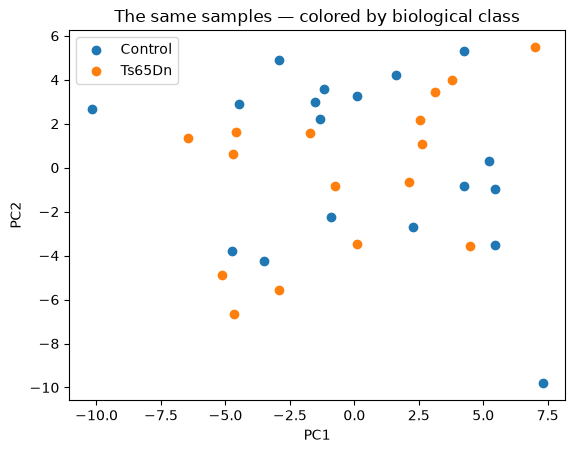

In [51]:
for label, group in pca_df.groupby("genotype"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("The same samples — colored by biological class")
plt.legend()
plt.show()

On PCA plot we don't see separate clusters based on Genotype, which can mean that we have effect not only from protein expression level.